<a href="https://colab.research.google.com/github/MO230101/Copolymer-lipid-interaction-study_ver.2/blob/main/%E3%80%87Visualization_of_ROI_Resolved_Meso_structure_Interaction_Preferences_for_NC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload:
 - ZG_to_FunctionalGroup_weights.csv
 - Copolymer_MI_caption_features.csv or Copolymer_change_based_motif_scores.csv


Saving Copolymer_change_based_motif_scores.csv to Copolymer_change_based_motif_scores.csv
Saving ZG_to_FunctionalGroup_weights.csv to ZG_to_FunctionalGroup_weights.csv
WEIGHT_PATH: /content/ZG_to_FunctionalGroup_weights.csv
MOTIF_PATH : /content/Copolymer_change_based_motif_scores.csv
[INFO] Loaded ZG_to_FunctionalGroup_weights.csv with encoding: utf-8-sig
[INFO] Loaded Copolymer_change_based_motif_scores.csv with encoding: utf-8-sig


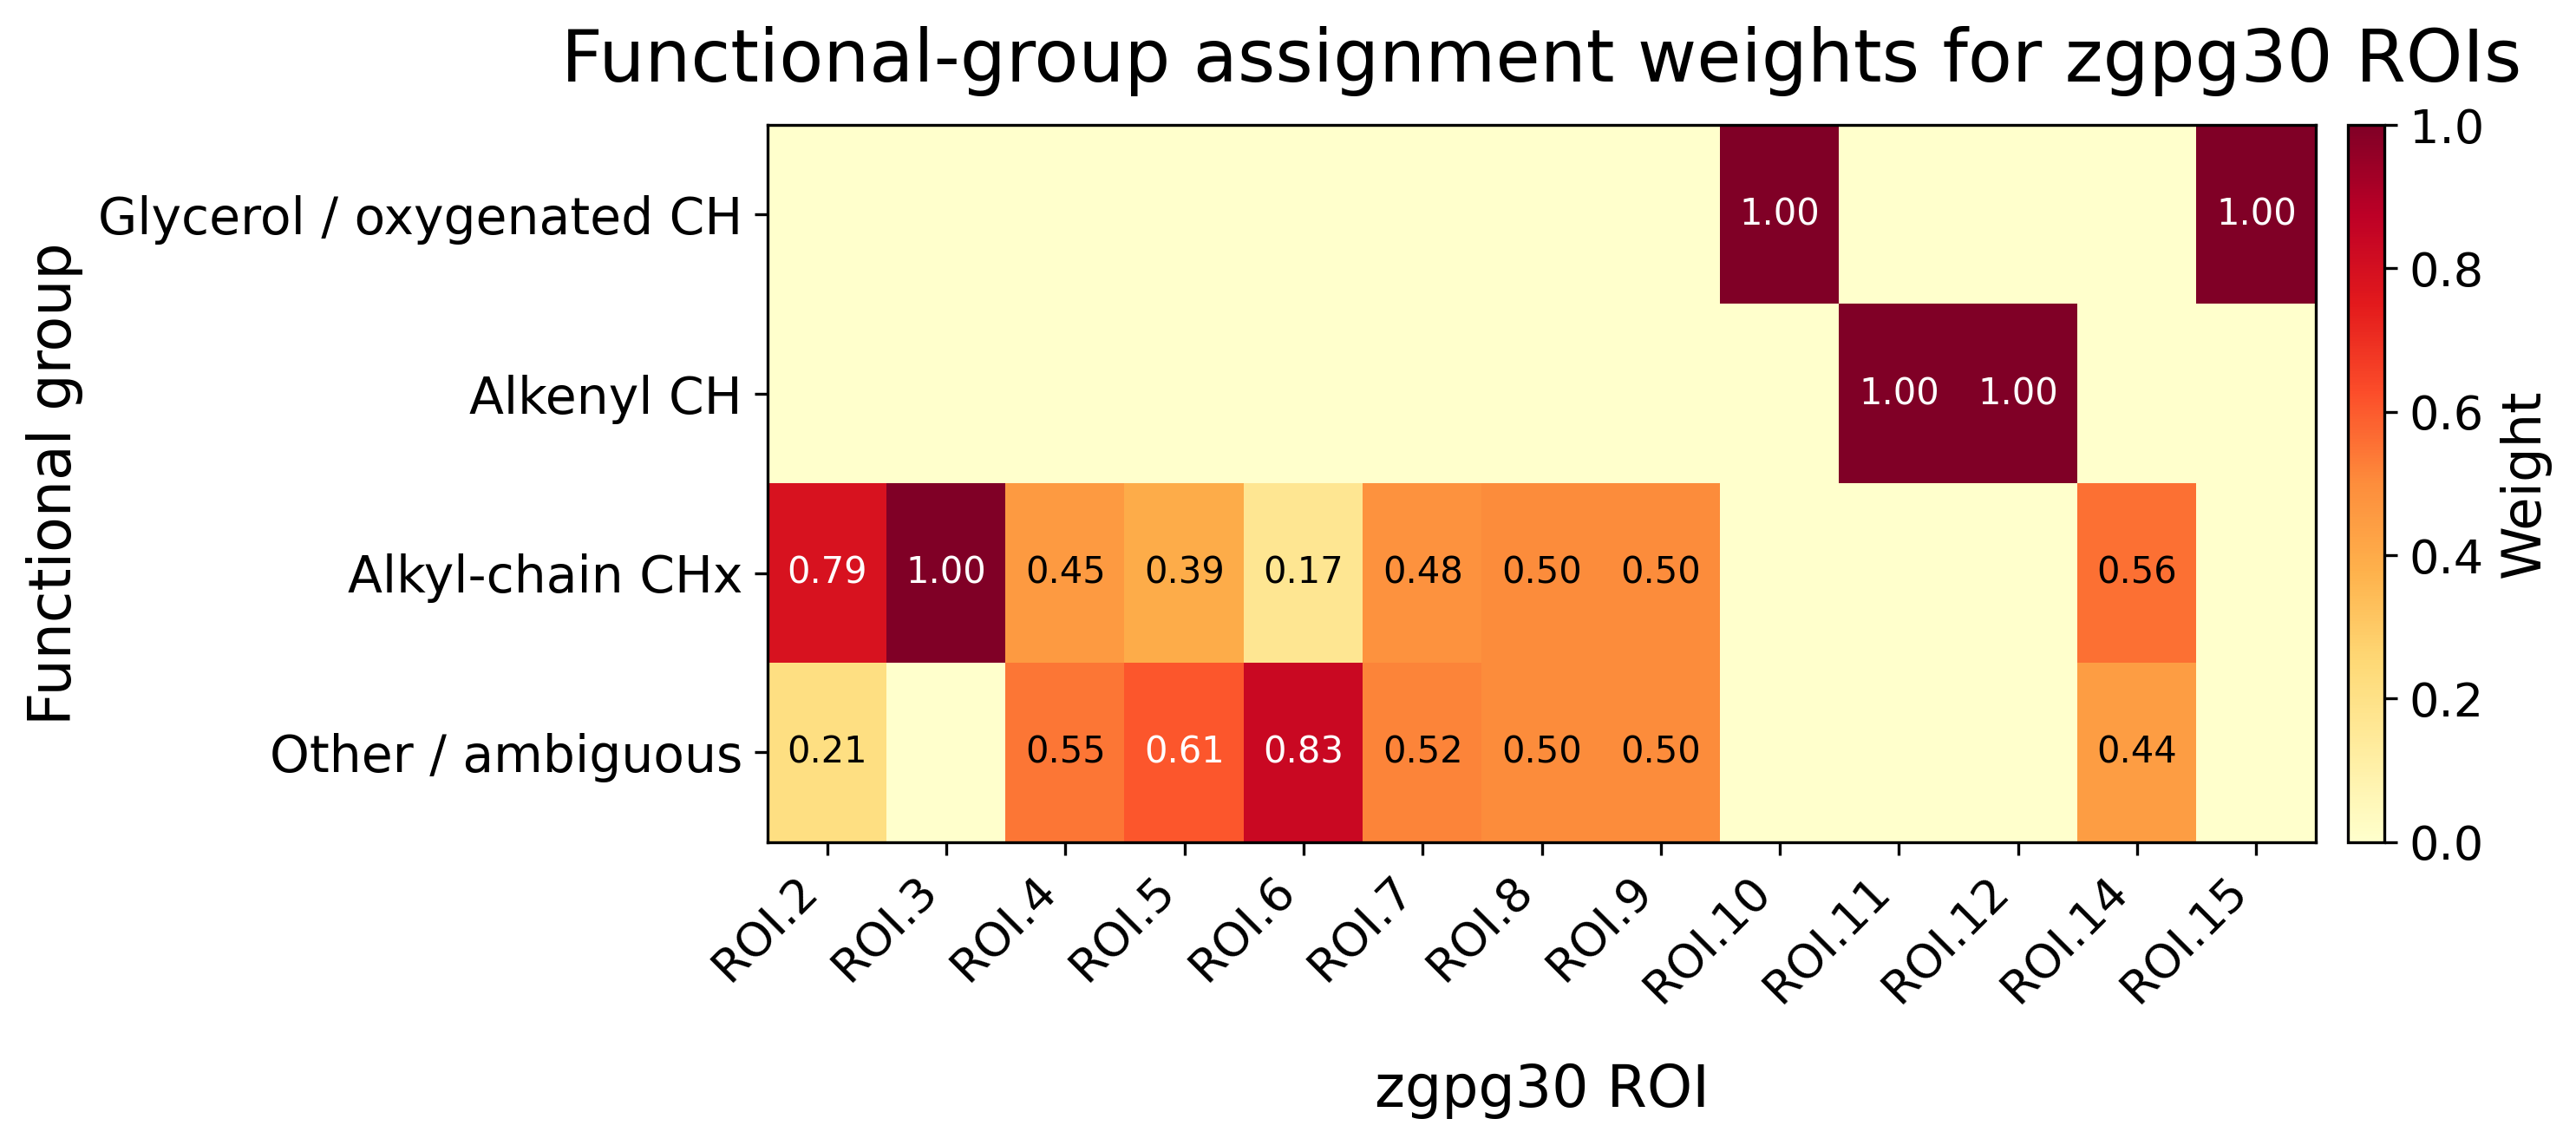

Saved:
 - /content/ZG_ROI_functional_group_heatmap_ROI_xaxis.png
 - /content/ZG_ROI_functional_group_heatmap_ROI_xaxis.pdf


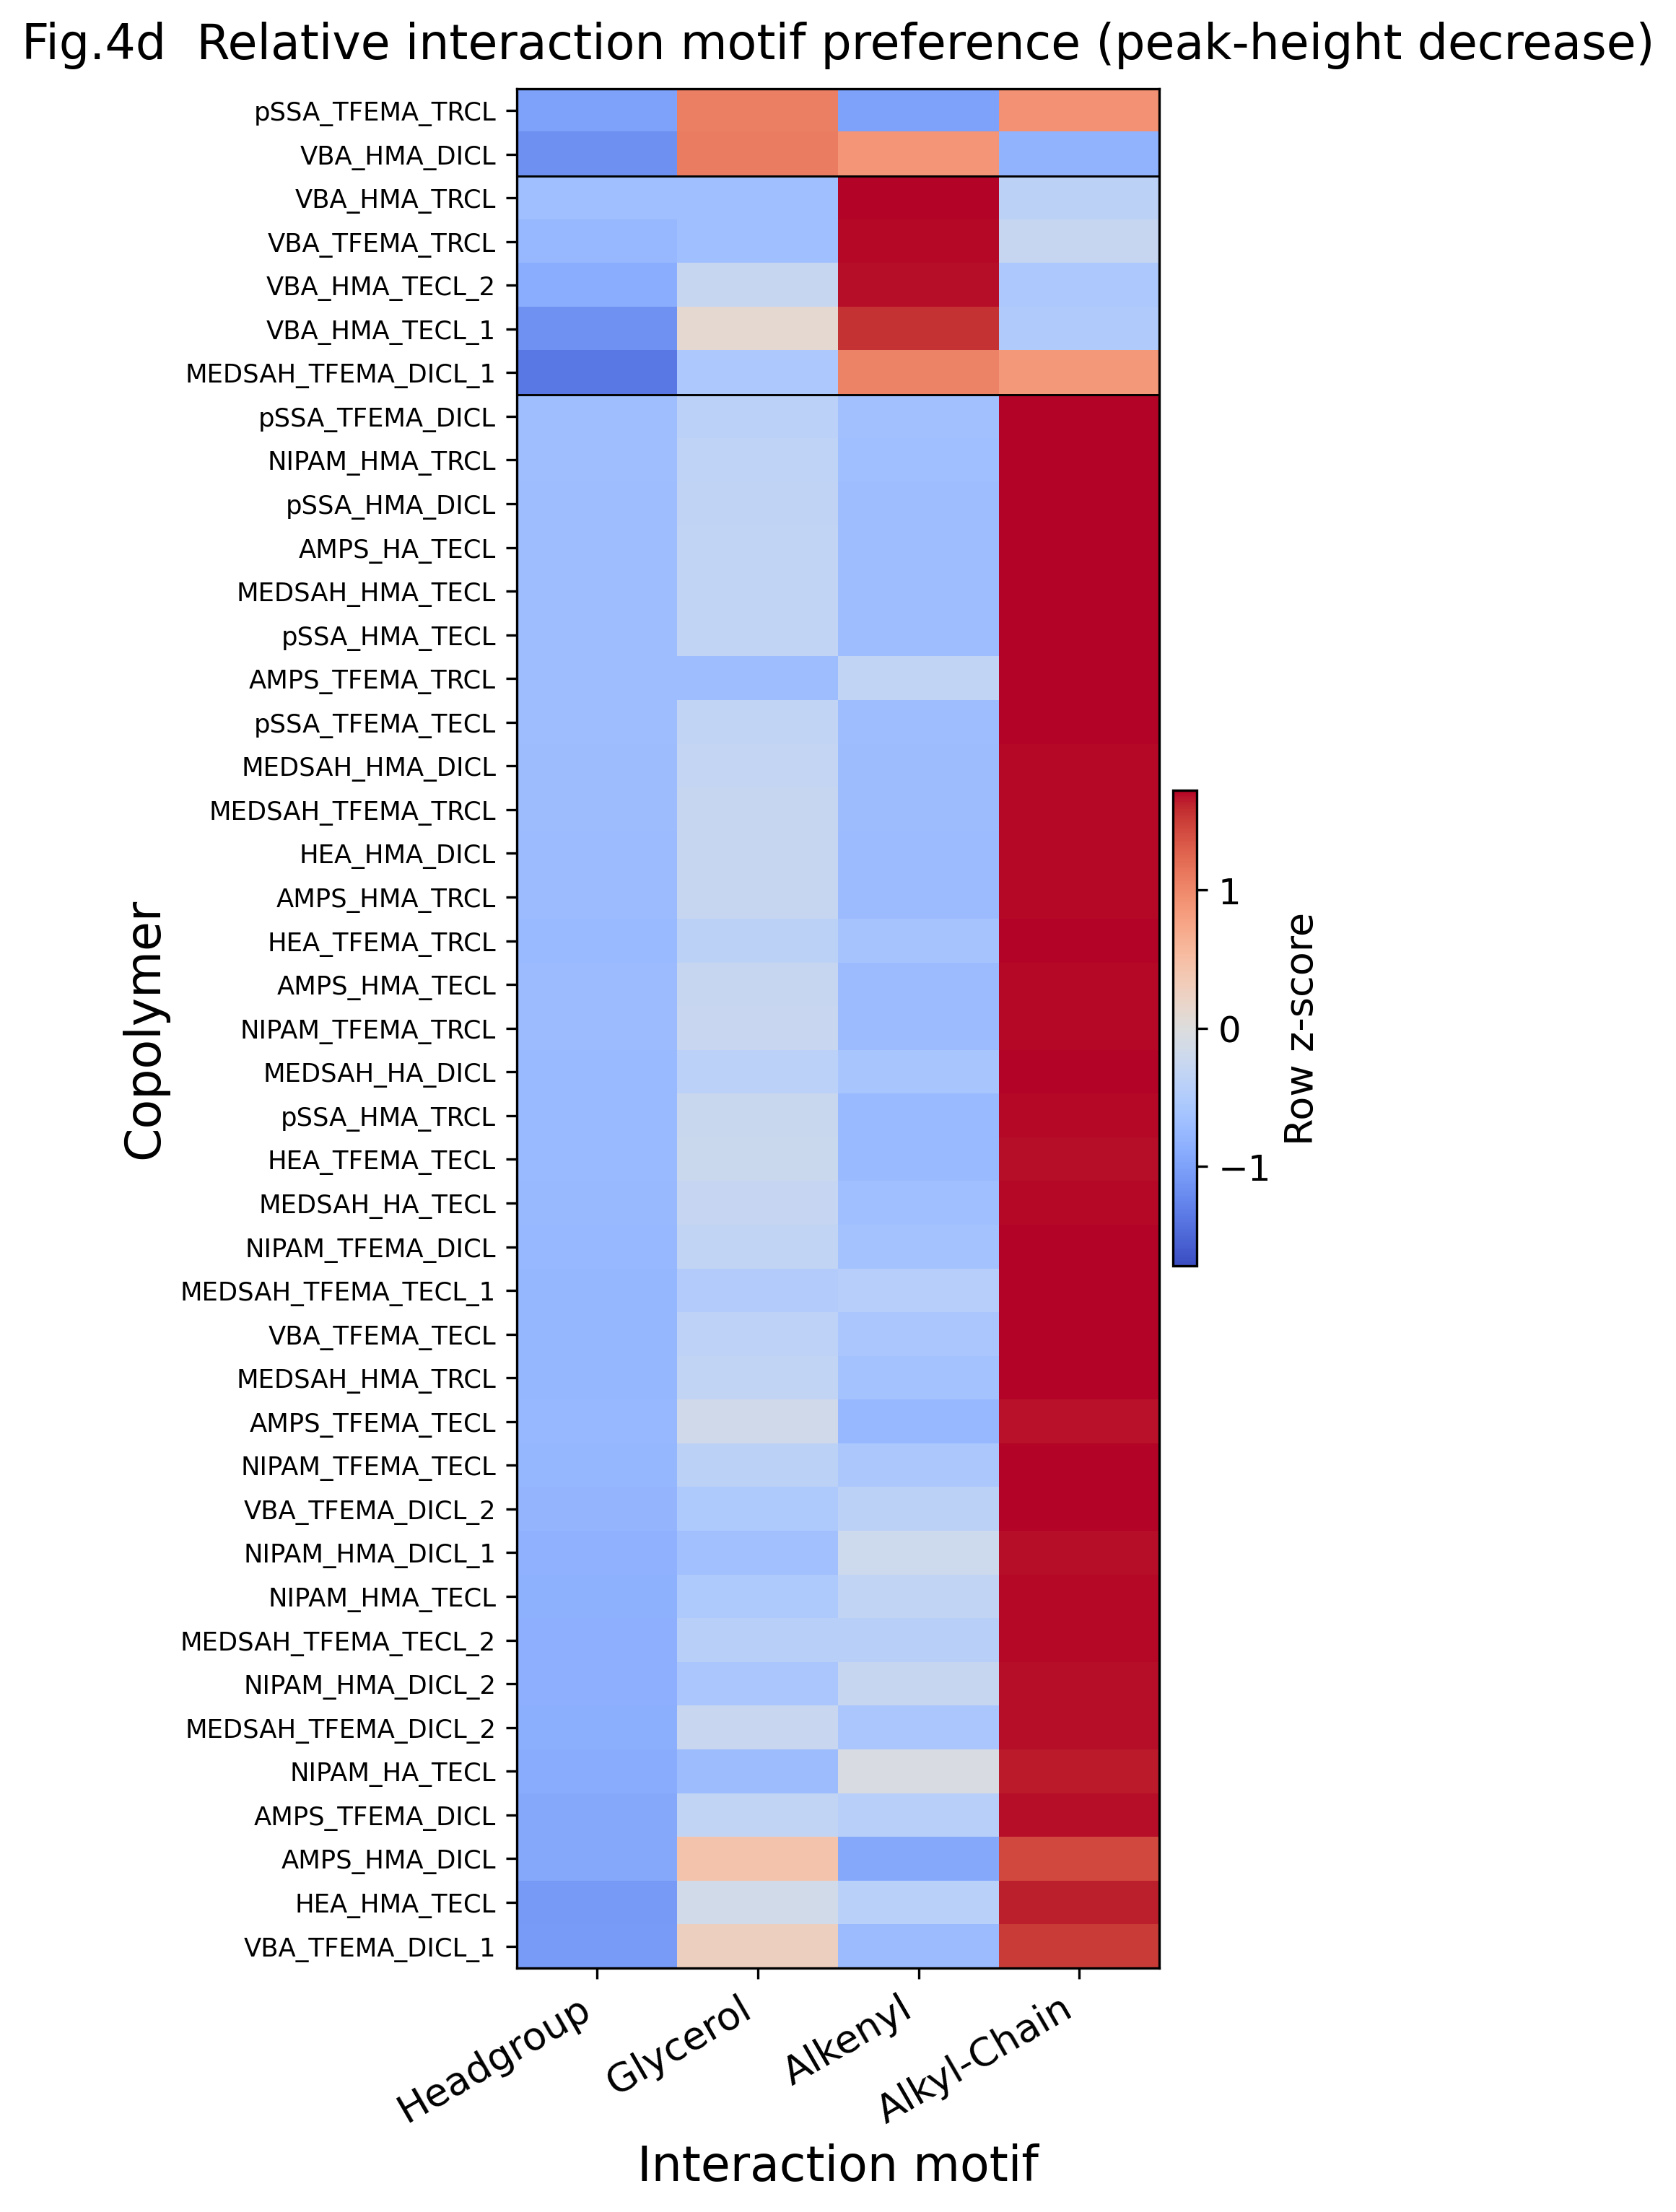

Saved:
 - /content/Fig4d_relative_interaction_motif_preference_clean_xlabel.png
 - /content/Fig4d_relative_interaction_motif_preference_clean_xlabel.pdf
Saved:
 - /content/Fig4d_relative_interaction_motif_preference_source_table.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ===============================================================
# Complete code:
# 1) Functional-group assignment weights heatmap for zgpg30 ROIs
#    - ROI numbers on X-axis
#    - high-value cells use white text
# 2) Fig.4d relative interaction motif preference heatmap
#    - x-axis labels omit "Delta Height Norm"
# ===============================================================

!pip -q install pandas numpy matplotlib openpyxl

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# ===============================================================
# 0. Upload if needed
# ===============================================================
def find_one(patterns):
    hits = []
    for p in patterns:
        hits.extend(glob.glob(p))
    hits = sorted(set(hits))
    return hits[0] if hits else None

WEIGHT_PATH = find_one([
    "/content/ZG_to_FunctionalGroup_weights.csv",
    "/content/*ZG_to_FunctionalGroup_weights*.csv",
])

MOTIF_PATH = find_one([
    "/content/Copolymer_MI_caption_features.csv",
    "/content/*Copolymer_MI_caption_features*.csv",
    "/content/Copolymer_change_based_motif_scores.csv",
    "/content/*Copolymer_change_based_motif_scores*.csv",
])

if WEIGHT_PATH is None or MOTIF_PATH is None:
    print("Please upload:")
    print(" - ZG_to_FunctionalGroup_weights.csv")
    print(" - Copolymer_MI_caption_features.csv or Copolymer_change_based_motif_scores.csv")
    files.upload()

WEIGHT_PATH = find_one([
    "/content/ZG_to_FunctionalGroup_weights.csv",
    "/content/*ZG_to_FunctionalGroup_weights*.csv",
])

MOTIF_PATH = find_one([
    "/content/Copolymer_MI_caption_features.csv",
    "/content/*Copolymer_MI_caption_features*.csv",
    "/content/Copolymer_change_based_motif_scores.csv",
    "/content/*Copolymer_change_based_motif_scores*.csv",
])

if WEIGHT_PATH is None:
    raise FileNotFoundError("ZG_to_FunctionalGroup_weights.csv not found.")
if MOTIF_PATH is None:
    raise FileNotFoundError("Copolymer_MI_caption_features.csv or Copolymer_change_based_motif_scores.csv not found.")

print("WEIGHT_PATH:", WEIGHT_PATH)
print("MOTIF_PATH :", MOTIF_PATH)

# ===============================================================
# 1. Reader
# ===============================================================
def robust_read_csv(path):
    last_err = None
    for enc in ["utf-8-sig", "utf-8", "cp932", "latin1"]:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"[INFO] Loaded {os.path.basename(path)} with encoding: {enc}")
            return df
        except Exception as e:
            last_err = e
    raise last_err

w_df = robust_read_csv(WEIGHT_PATH)
m_df = robust_read_csv(MOTIF_PATH)

w_df.columns = [str(c).strip() for c in w_df.columns]
m_df.columns = [str(c).strip() for c in m_df.columns]

# ===============================================================
# 2. Common utilities
# ===============================================================
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300

def normalize_roi_name(x):
    s = str(x).strip()
    s = s.replace("ROI ", "ROI.")
    s = s.replace("ROI_", "ROI.")
    s = s.replace("ROI-", "ROI.")
    m = re.search(r"ROI\.?(\d+)", s, flags=re.IGNORECASE)
    if m:
        return f"ROI.{m.group(1)}"
    return s

def roi_sort_key(x):
    m = re.search(r"(\d+)", str(x))
    return int(m.group(1)) if m else 999

def normalize_fg_name(x):
    s = str(x).strip().lower()
    s = s.replace("/", "_")
    s = s.replace("-", "_")
    s = re.sub(r"__+", "_", s).strip("_")
    return s

def prettify_fg_name(x):
    mapping = {
        "headgroup_polar_ch": "Headgroup / polar CH",
        "glycerol_oxygenated_ch": "Glycerol / oxygenated CH",
        "alkenyl_ch": "Alkenyl CH",
        "alkyl_chain_chx": "Alkyl-chain CHx",
        "oxygenated_aliphatic_other": "Oxygenated aliphatic",
        "carbonyl_ester_like": "Carbonyl / ester-like",
        "other_ambiguous": "Other / ambiguous",
    }
    return mapping.get(str(x), str(x).replace("_", " ").title())

def row_zscore(arr):
    arr = np.asarray(arr, dtype=float)
    if np.all(~np.isfinite(arr)):
        return np.full_like(arr, np.nan, dtype=float)
    m = np.nanmean(arr)
    s = np.nanstd(arr)
    if not np.isfinite(s) or s == 0:
        return np.zeros_like(arr, dtype=float)
    return (arr - m) / s

# ===============================================================
# 3. Figure 1:
# Functional-group assignment weights for zgpg30 ROIs
# ROI numbers on X-axis
# ===============================================================
required_w = ["ZG_ROI", "FunctionalGroup", "weight"]
missing_w = [c for c in required_w if c not in w_df.columns]
if missing_w:
    raise ValueError(f"Weight file is missing columns: {missing_w}")

w_df["ZG_ROI"] = w_df["ZG_ROI"].apply(normalize_roi_name)
w_df["FunctionalGroup"] = w_df["FunctionalGroup"].apply(normalize_fg_name)
w_df["weight"] = pd.to_numeric(w_df["weight"], errors="coerce").fillna(0.0)

fg_order = [
    "glycerol_oxygenated_ch",
    "alkenyl_ch",
    "alkyl_chain_chx",
    "other_ambiguous",
]

fg_order = [fg for fg in fg_order if fg in set(w_df["FunctionalGroup"])]
extra_fgs = [
    fg for fg in sorted(w_df["FunctionalGroup"].unique())
    if fg not in fg_order
]
fg_order = fg_order + extra_fgs

roi_order = sorted(w_df["ZG_ROI"].dropna().unique(), key=roi_sort_key)

# ★ 修正点：indexをFunctionalGroup、columnsをZG_ROIに変更
weight_mat = (
    w_df.pivot_table(
        index="FunctionalGroup",
        columns="ZG_ROI",
        values="weight",
        aggfunc="sum",
        fill_value=0.0
    )
    .reindex(index=fg_order, columns=roi_order, fill_value=0.0)
)

fig_w = max(10, 0.42 * len(weight_mat.columns))
fig_h = max(4.5, 0.7 * len(weight_mat.index))
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

im = ax.imshow(
    weight_mat.values,
    aspect="auto",
    interpolation="nearest",
    cmap="YlOrRd",
    vmin=0,
    vmax=1
)

ax.set_title(
    "Functional-group assignment weights for zgpg30 ROIs",
    fontsize=20,
    pad=12
)

# ★ 修正点：X軸をROI、Y軸をFunctional groupに変更
ax.set_xlabel("zgpg30 ROI", fontsize=16, labelpad=14)
ax.set_ylabel("Functional group", fontsize=16)

ax.set_xticks(np.arange(weight_mat.shape[1]))
ax.set_xticklabels(
    weight_mat.columns.tolist(),
    rotation=45,
    ha="right",
    fontsize=13
)

ax.set_yticks(np.arange(weight_mat.shape[0]))
ax.set_yticklabels(
    [prettify_fg_name(c) for c in weight_mat.index],
    fontsize=14
)

# 数値ラベル：濃いセルは白文字
for i in range(weight_mat.shape[0]):
    for j in range(weight_mat.shape[1]):
        val = weight_mat.iloc[i, j]
        if val > 0:
            text_color = "white" if val >= 0.60 else "black"
            ax.text(
                j, i, f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=10,
                color=text_color
            )

cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Weight", fontsize=15)
cbar.ax.tick_params(labelsize=13)

plt.tight_layout()

OUT1_PNG = "/content/ZG_ROI_functional_group_heatmap_ROI_xaxis.png"
OUT1_PDF = "/content/ZG_ROI_functional_group_heatmap_ROI_xaxis.pdf"
plt.savefig(OUT1_PNG, bbox_inches="tight")
plt.savefig(OUT1_PDF, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:")
print(" -", OUT1_PNG)
print(" -", OUT1_PDF)

# ===============================================================
# 4. Figure 2:
# Fig.4d Relative interaction motif preference
# ===============================================================
if all(c in m_df.columns for c in [
    "headgroup_delta_height_norm",
    "glycerol_delta_height_norm",
    "alkenyl_delta_height_norm",
    "alkyl_chain_delta_height_norm",
]):
    heat_cols = [
        "headgroup_delta_height_norm",
        "glycerol_delta_height_norm",
        "alkenyl_delta_height_norm",
        "alkyl_chain_delta_height_norm",
    ]
elif all(c in m_df.columns for c in [
    "headgroup_delta_auc_norm",
    "glycerol_delta_auc_norm",
    "alkenyl_delta_auc_norm",
    "alkyl_chain_delta_auc_norm",
]):
    heat_cols = [
        "headgroup_delta_auc_norm",
        "glycerol_delta_auc_norm",
        "alkenyl_delta_auc_norm",
        "alkyl_chain_delta_auc_norm",
    ]
else:
    raise ValueError(
        "Motif file must contain delta_height_norm or delta_auc_norm motif columns."
    )

if "Copolymer_Name" not in m_df.columns:
    raise ValueError("Motif file must contain Copolymer_Name column.")

def prettify_motif_col(c):
    s = str(c)
    s = s.replace("_delta_height_norm", "")
    s = s.replace("_delta_auc_norm", "")
    s = s.replace("headgroup", "Headgroup")
    s = s.replace("glycerol", "Glycerol")
    s = s.replace("alkenyl", "Alkenyl")
    s = s.replace("alkyl_chain", "Alkyl-Chain")
    return s

if "dominant_height_motif" in m_df.columns:
    dominant_col = "dominant_height_motif"
elif "I_dominant_motif" in m_df.columns:
    dominant_col = "I_dominant_motif"
else:
    dominant_col = "__dominant_motif"
    vals = m_df[heat_cols].to_numpy(dtype=float)
    doms = []
    motif_names = ["headgroup", "glycerol", "alkenyl", "alkyl_chain"]
    for row in vals:
        if np.all(~np.isfinite(row)):
            doms.append("unknown")
        else:
            doms.append(motif_names[int(np.nanargmax(row))])
    m_df[dominant_col] = doms

dominant_order = ["headgroup", "glycerol", "alkenyl", "alkyl_chain", "unknown"]
dom_rank = {k: i for i, k in enumerate(dominant_order)}

m_df["__dominant_rank"] = m_df[dominant_col].map(dom_rank).fillna(99)

def within_group_key(row):
    d = row[dominant_col]
    if d == "headgroup":
        return row[heat_cols[0]]
    if d == "glycerol":
        return row[heat_cols[1]]
    if d == "alkenyl":
        return row[heat_cols[2]]
    if d == "alkyl_chain":
        return row[heat_cols[3]]
    return 0.0

m_df["__within_group_key"] = m_df.apply(within_group_key, axis=1)

m_plot = m_df.sort_values(
    ["__dominant_rank", "__within_group_key", "Copolymer_Name"],
    ascending=[True, False, True]
).reset_index(drop=True)

norm_mat = m_plot[heat_cols].to_numpy(dtype=float)
row_z = np.vstack([row_zscore(row) for row in norm_mat])

fig_h = max(9, 0.24 * len(m_plot))
fig, ax = plt.subplots(figsize=(6.0, fig_h))

vabs = np.nanmax(np.abs(row_z))
if not np.isfinite(vabs) or vabs == 0:
    vabs = 1.0

im = ax.imshow(
    row_z,
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm",
    vmin=-vabs,
    vmax=vabs
)

ax.set_title(
    "Fig.4d  Relative interaction motif preference (peak-height decrease)",
    fontsize=16,
    pad=10
)
ax.set_xlabel("Interaction motif", fontsize=16)
ax.set_ylabel("Copolymer", fontsize=16)

ax.set_xticks(np.arange(len(heat_cols)))
ax.set_xticklabels(
    [prettify_motif_col(c) for c in heat_cols],
    rotation=30,
    ha="right",
    fontsize=13
)

ax.set_yticks(np.arange(len(m_plot)))
ax.set_yticklabels(m_plot["Copolymer_Name"].tolist(), fontsize=8.5)

prev = None
for i, d in enumerate(m_plot[dominant_col].tolist()):
    if prev is None:
        prev = d
        continue
    if d != prev:
        ax.axhline(i - 0.5, color="black", lw=0.7)
        prev = d

cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Row z-score", fontsize=13)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()

OUT2_PNG = "/content/Fig4d_relative_interaction_motif_preference_clean_xlabel.png"
OUT2_PDF = "/content/Fig4d_relative_interaction_motif_preference_clean_xlabel.pdf"
plt.savefig(OUT2_PNG, bbox_inches="tight")
plt.savefig(OUT2_PDF, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:")
print(" -", OUT2_PNG)
print(" -", OUT2_PDF)

# ===============================================================
# 5. Save Fig.4d source table
# ===============================================================
source_df = m_plot[["Copolymer_Name", dominant_col] + heat_cols].copy()
source_df["dominant_motif_for_sorting"] = source_df[dominant_col]

for j, c in enumerate(heat_cols):
    source_df[c + "_row_zscore"] = row_z[:, j]

OUT_TABLE = "/content/Fig4d_relative_interaction_motif_preference_source_table.csv"
source_df.to_csv(OUT_TABLE, index=False, encoding="utf-8-sig")

print("Saved:")
print(" -", OUT_TABLE)

# ===============================================================
# 6. Download
# ===============================================================
files.download(OUT1_PNG)
files.download(OUT1_PDF)
files.download(OUT2_PNG)
files.download(OUT2_PDF)
files.download(OUT_TABLE)

WEIGHT_PATH: /content/ZG_to_FunctionalGroup_weights.csv
MOTIF_PATH : /content/Copolymer_MI_caption_features.csv
[INFO] Loaded ZG_to_FunctionalGroup_weights.csv with encoding: utf-8-sig
[INFO] Loaded Copolymer_MI_caption_features.csv with encoding: utf-8-sig


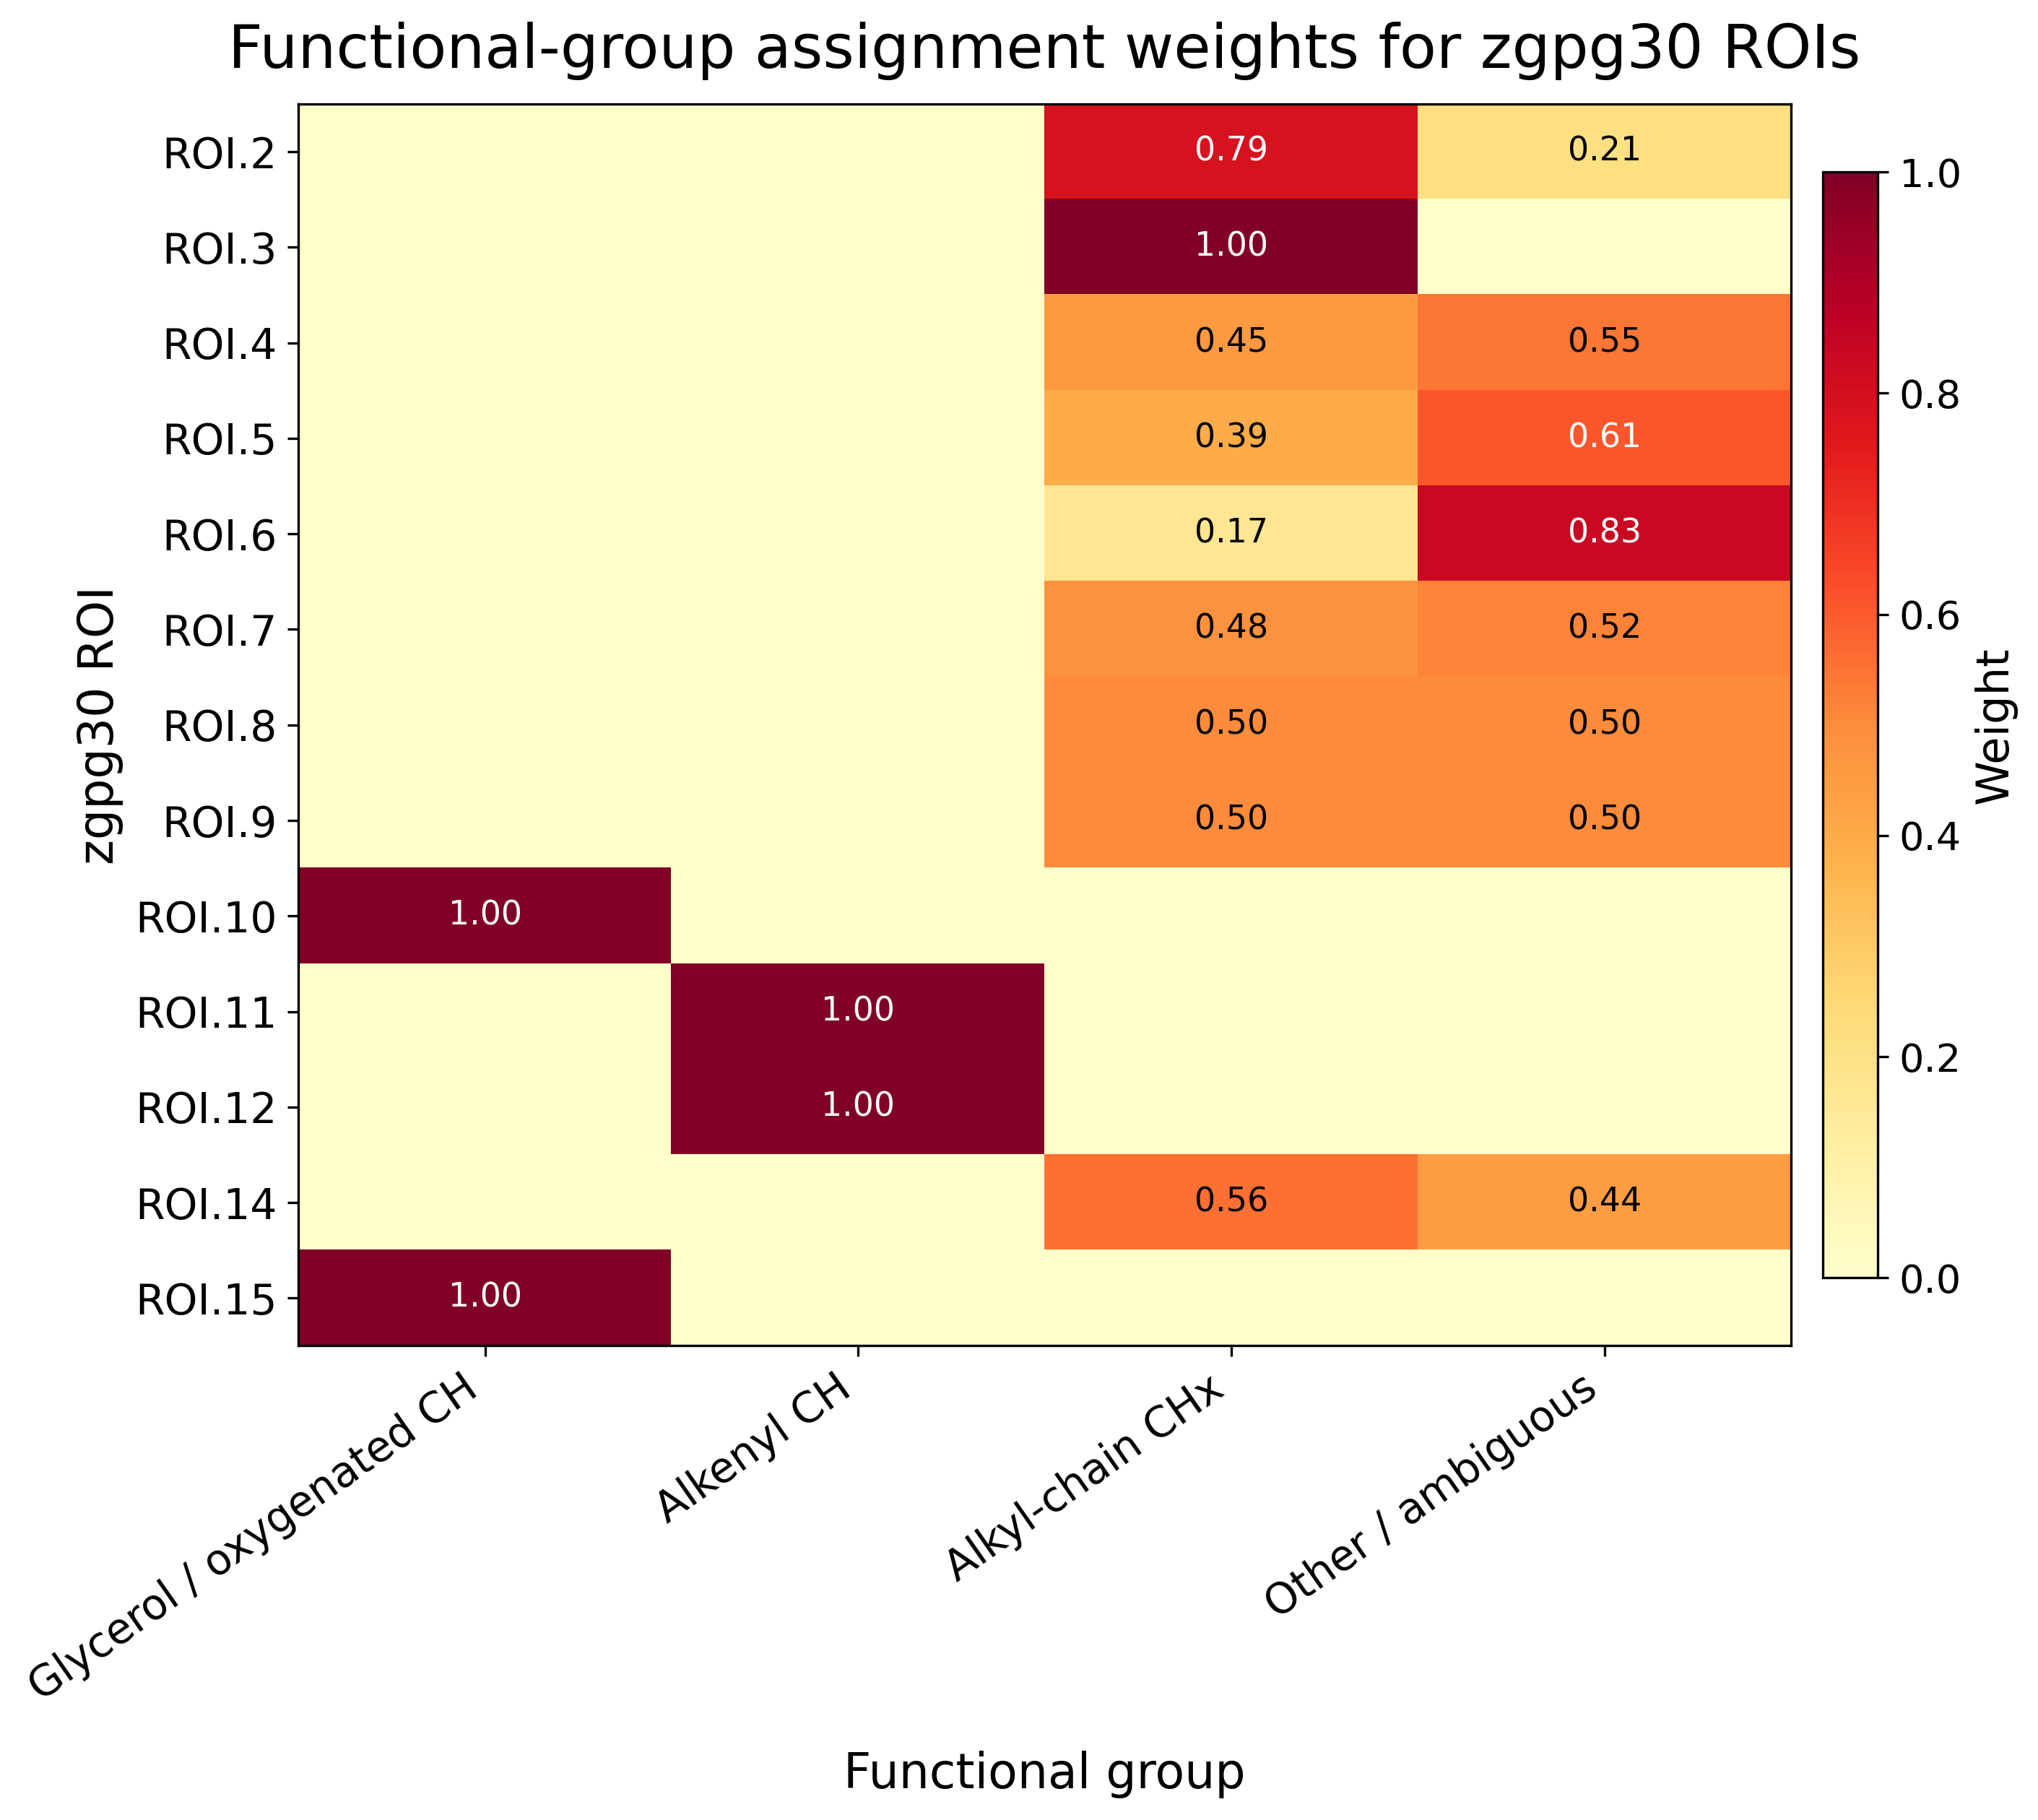

Saved:
 - /content/ZG_ROI_functional_group_heatmap_white_text.png
 - /content/ZG_ROI_functional_group_heatmap_white_text.pdf


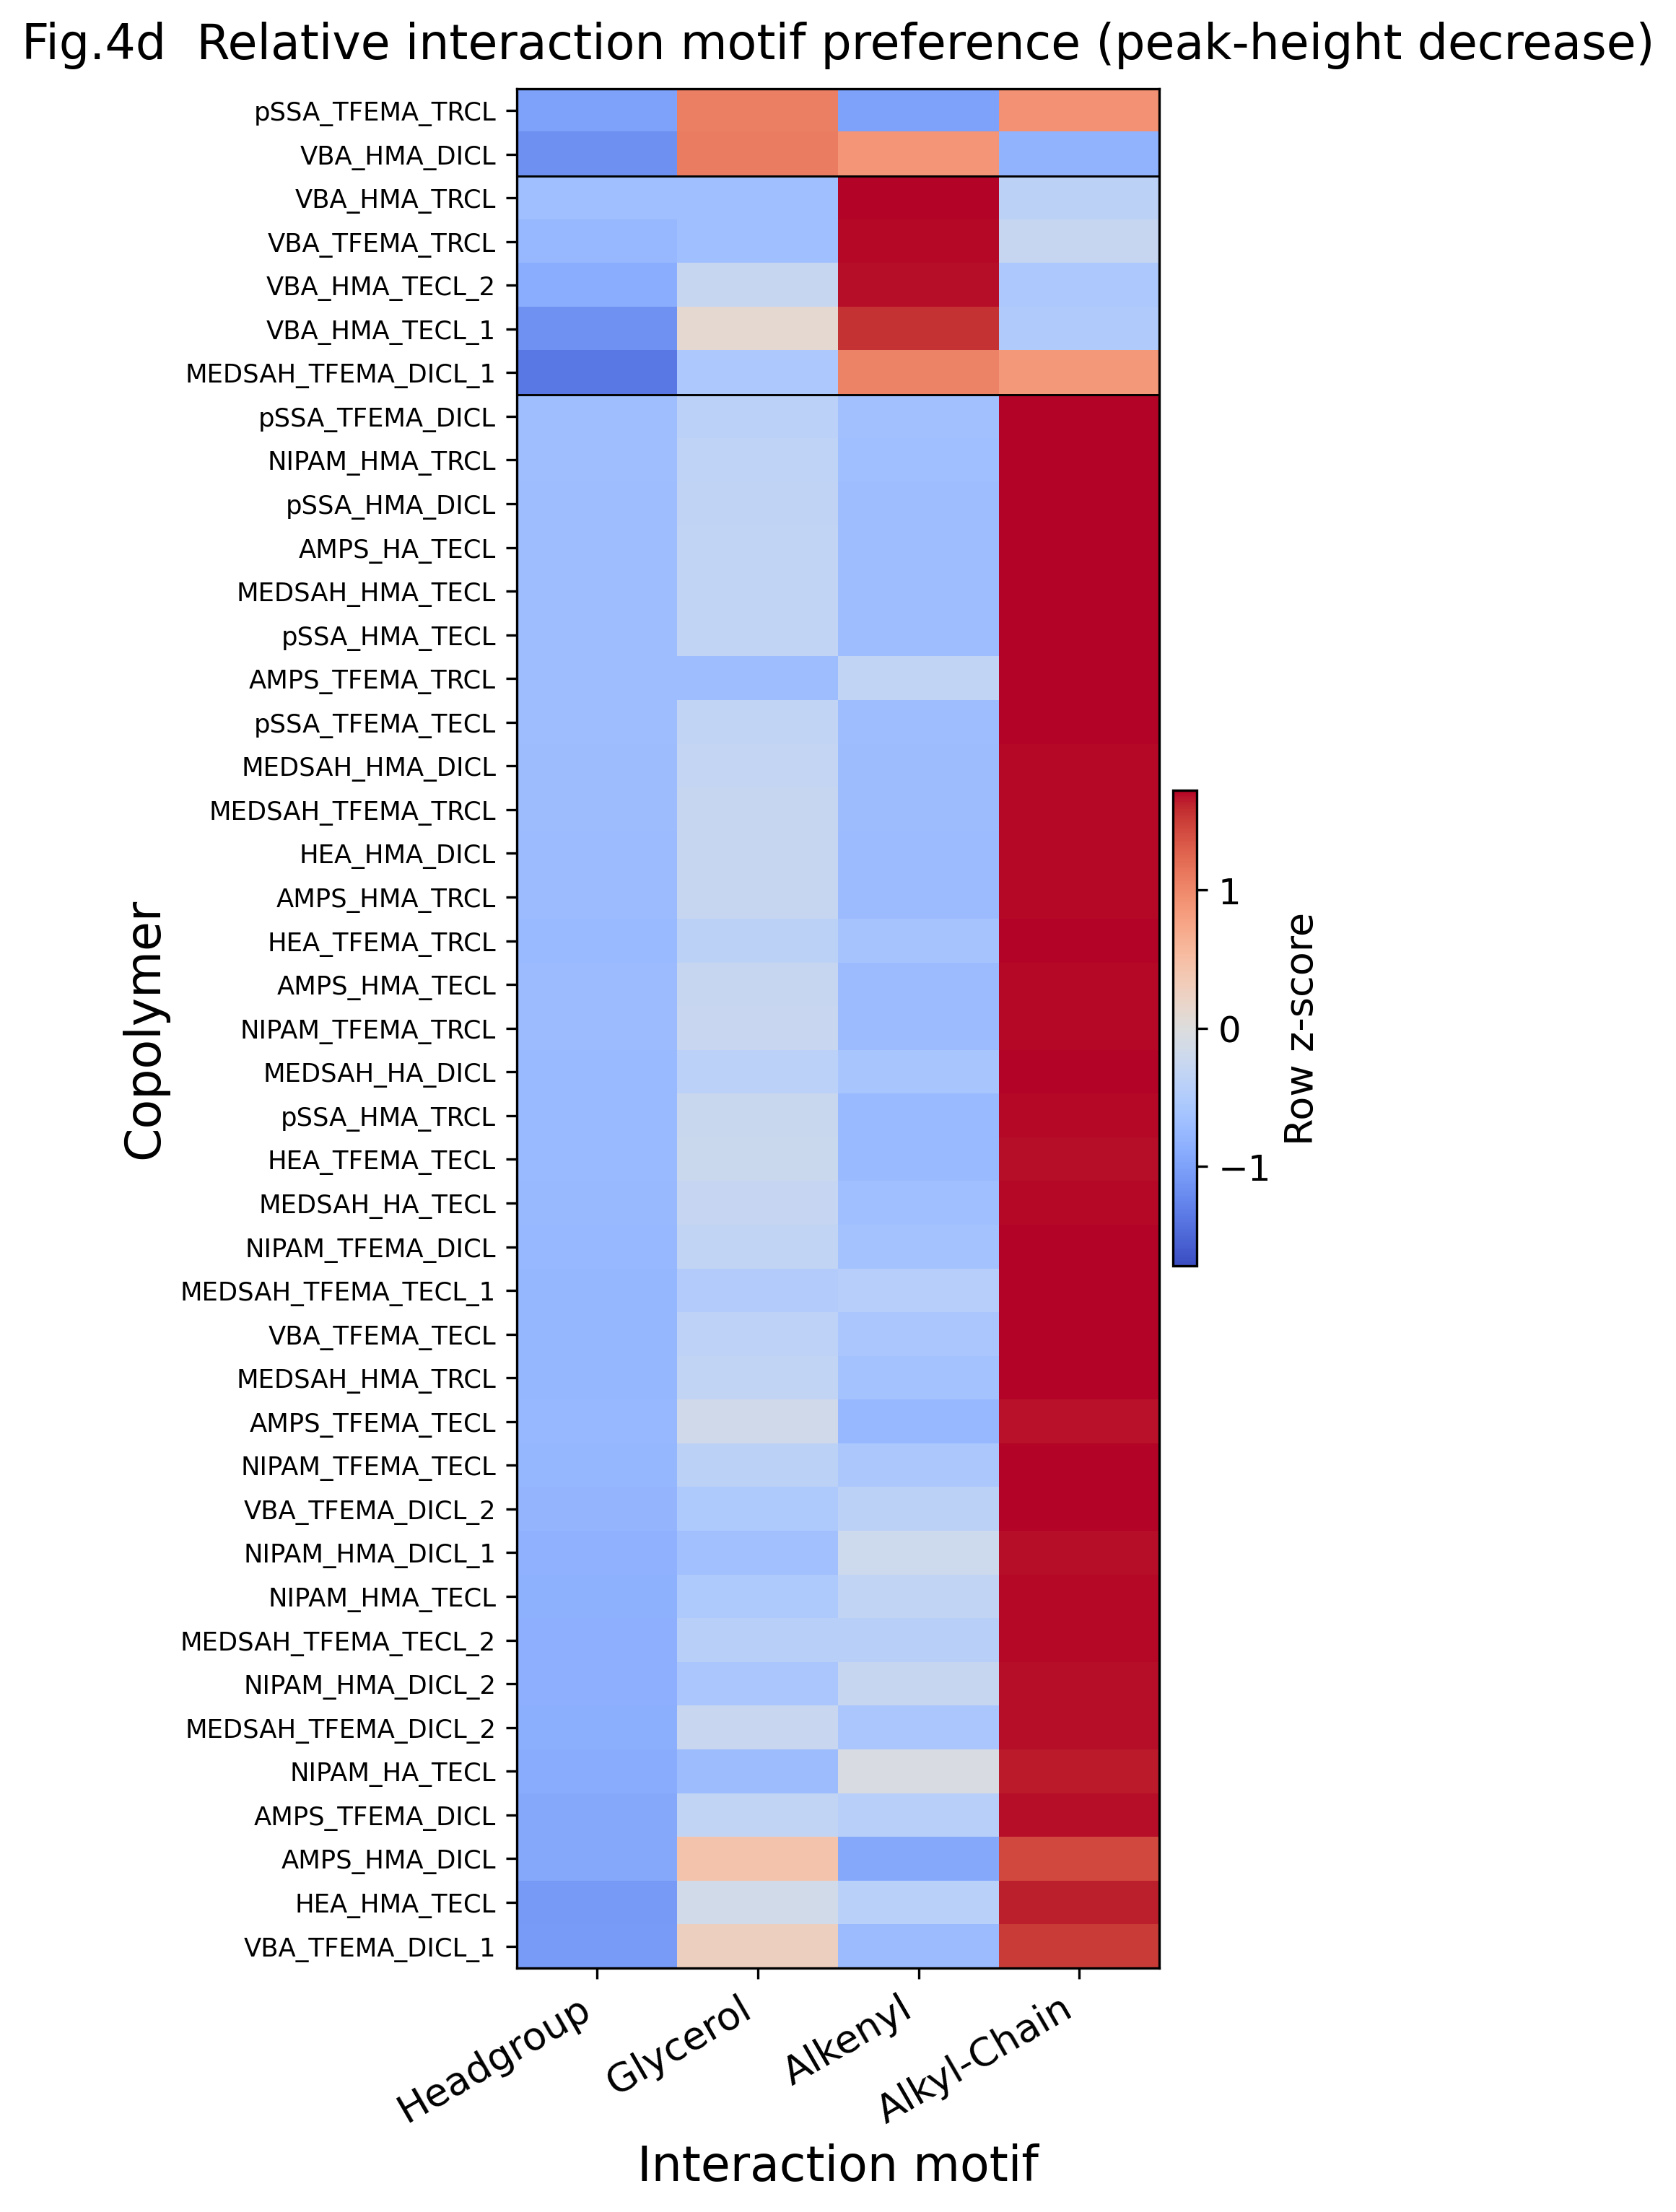

Saved:
 - /content/Fig4d_relative_interaction_motif_preference_clean_xlabel.png
 - /content/Fig4d_relative_interaction_motif_preference_clean_xlabel.pdf
Saved:
 - /content/Fig4d_relative_interaction_motif_preference_source_table.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ===============================================================
# Complete code:
# 1) Functional-group assignment weights heatmap for zgpg30 ROIs
#    - high-value cells use white text
# 2) Fig.4d relative interaction motif preference heatmap
#    - x-axis labels omit "Delta Height Norm"
#
# Required files:
#   - ZG_to_FunctionalGroup_weights.csv
#   - Copolymer_MI_caption_features.csv
#     OR Copolymer_change_based_motif_scores.csv
# ===============================================================

!pip -q install pandas numpy matplotlib openpyxl

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# ===============================================================
# 0. Upload if needed
# ===============================================================
def find_one(patterns):
    hits = []
    for p in patterns:
        hits.extend(glob.glob(p))
    hits = sorted(set(hits))
    return hits[0] if hits else None

WEIGHT_PATH = find_one([
    "/content/ZG_to_FunctionalGroup_weights.csv",
    "/content/*ZG_to_FunctionalGroup_weights*.csv",
])

MOTIF_PATH = find_one([
    "/content/Copolymer_MI_caption_features.csv",
    "/content/*Copolymer_MI_caption_features*.csv",
    "/content/Copolymer_change_based_motif_scores.csv",
    "/content/*Copolymer_change_based_motif_scores*.csv",
])

if WEIGHT_PATH is None or MOTIF_PATH is None:
    print("Please upload:")
    print(" - ZG_to_FunctionalGroup_weights.csv")
    print(" - Copolymer_MI_caption_features.csv or Copolymer_change_based_motif_scores.csv")
    files.upload()

WEIGHT_PATH = find_one([
    "/content/ZG_to_FunctionalGroup_weights.csv",
    "/content/*ZG_to_FunctionalGroup_weights*.csv",
])

MOTIF_PATH = find_one([
    "/content/Copolymer_MI_caption_features.csv",
    "/content/*Copolymer_MI_caption_features*.csv",
    "/content/Copolymer_change_based_motif_scores.csv",
    "/content/*Copolymer_change_based_motif_scores*.csv",
])

if WEIGHT_PATH is None:
    raise FileNotFoundError("ZG_to_FunctionalGroup_weights.csv not found.")
if MOTIF_PATH is None:
    raise FileNotFoundError("Copolymer_MI_caption_features.csv or Copolymer_change_based_motif_scores.csv not found.")

print("WEIGHT_PATH:", WEIGHT_PATH)
print("MOTIF_PATH :", MOTIF_PATH)

# ===============================================================
# 1. Reader
# ===============================================================
def robust_read_csv(path):
    last_err = None
    for enc in ["utf-8-sig", "utf-8", "cp932", "latin1"]:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"[INFO] Loaded {os.path.basename(path)} with encoding: {enc}")
            return df
        except Exception as e:
            last_err = e
    raise last_err

w_df = robust_read_csv(WEIGHT_PATH)
m_df = robust_read_csv(MOTIF_PATH)

w_df.columns = [str(c).strip() for c in w_df.columns]
m_df.columns = [str(c).strip() for c in m_df.columns]

# ===============================================================
# 2. Common utilities
# ===============================================================
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300

def normalize_roi_name(x):
    s = str(x).strip()
    s = s.replace("ROI ", "ROI.")
    s = s.replace("ROI_", "ROI.")
    s = s.replace("ROI-", "ROI.")
    m = re.search(r"ROI\.?(\d+)", s, flags=re.IGNORECASE)
    if m:
        return f"ROI.{m.group(1)}"
    return s

def roi_sort_key(x):
    m = re.search(r"(\d+)", str(x))
    return int(m.group(1)) if m else 999

def normalize_fg_name(x):
    s = str(x).strip().lower()
    s = s.replace("/", "_")
    s = s.replace("-", "_")
    s = re.sub(r"__+", "_", s).strip("_")
    return s

def prettify_fg_name(x):
    mapping = {
        "headgroup_polar_ch": "Headgroup / polar CH",
        "glycerol_oxygenated_ch": "Glycerol / oxygenated CH",
        "alkenyl_ch": "Alkenyl CH",
        "alkyl_chain_chx": "Alkyl-chain CHx",
        "oxygenated_aliphatic_other": "Oxygenated aliphatic",
        "carbonyl_ester_like": "Carbonyl / ester-like",
        "other_ambiguous": "Other / ambiguous",
    }
    return mapping.get(str(x), str(x).replace("_", " ").title())

def row_zscore(arr):
    arr = np.asarray(arr, dtype=float)
    if np.all(~np.isfinite(arr)):
        return np.full_like(arr, np.nan, dtype=float)
    m = np.nanmean(arr)
    s = np.nanstd(arr)
    if not np.isfinite(s) or s == 0:
        return np.zeros_like(arr, dtype=float)
    return (arr - m) / s

# ===============================================================
# 3. Figure 1:
# Functional-group assignment weights for zgpg30 ROIs
# ===============================================================
required_w = ["ZG_ROI", "FunctionalGroup", "weight"]
missing_w = [c for c in required_w if c not in w_df.columns]
if missing_w:
    raise ValueError(f"Weight file is missing columns: {missing_w}")

w_df["ZG_ROI"] = w_df["ZG_ROI"].apply(normalize_roi_name)
w_df["FunctionalGroup"] = w_df["FunctionalGroup"].apply(normalize_fg_name)
w_df["weight"] = pd.to_numeric(w_df["weight"], errors="coerce").fillna(0.0)

fg_order = [
    "glycerol_oxygenated_ch",
    "alkenyl_ch",
    "alkyl_chain_chx",
    "other_ambiguous",
]

fg_order = [fg for fg in fg_order if fg in set(w_df["FunctionalGroup"])]
extra_fgs = [
    fg for fg in sorted(w_df["FunctionalGroup"].unique())
    if fg not in fg_order
]
fg_order = fg_order + extra_fgs

roi_order = sorted(w_df["ZG_ROI"].dropna().unique(), key=roi_sort_key)

weight_mat = (
    w_df.pivot_table(
        index="ZG_ROI",
        columns="FunctionalGroup",
        values="weight",
        aggfunc="sum",
        fill_value=0.0
    )
    .reindex(index=roi_order, columns=fg_order, fill_value=0.0)
)

fig, ax = plt.subplots(figsize=(9.5, 8.5))

im = ax.imshow(
    weight_mat.values,
    aspect="auto",
    interpolation="nearest",
    cmap="YlOrRd",
    vmin=0,
    vmax=1
)

ax.set_title(
    "Functional-group assignment weights for zgpg30 ROIs",
    fontsize=20,
    pad=12
)
ax.set_xlabel("Functional group", fontsize=16, labelpad=14)
ax.set_ylabel("zgpg30 ROI", fontsize=16)

ax.set_xticks(np.arange(weight_mat.shape[1]))
ax.set_xticklabels(
    [prettify_fg_name(c) for c in weight_mat.columns],
    rotation=35,
    ha="right",
    fontsize=14
)

ax.set_yticks(np.arange(weight_mat.shape[0]))
ax.set_yticklabels(weight_mat.index.tolist(), fontsize=14)

# 数値ラベル：濃いセルは白文字
for i in range(weight_mat.shape[0]):
    for j in range(weight_mat.shape[1]):
        val = weight_mat.iloc[i, j]
        if val > 0:
            text_color = "white" if val >= 0.60 else "black"
            ax.text(
                j, i, f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=11,
                color=text_color
            )

cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Weight", fontsize=15)
cbar.ax.tick_params(labelsize=13)

plt.tight_layout()

OUT1_PNG = "/content/ZG_ROI_functional_group_heatmap_white_text.png"
OUT1_PDF = "/content/ZG_ROI_functional_group_heatmap_white_text.pdf"
plt.savefig(OUT1_PNG, bbox_inches="tight")
plt.savefig(OUT1_PDF, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:")
print(" -", OUT1_PNG)
print(" -", OUT1_PDF)

# ===============================================================
# 4. Figure 2:
# Fig.4d Relative interaction motif preference
# ===============================================================
if all(c in m_df.columns for c in [
    "headgroup_delta_height_norm",
    "glycerol_delta_height_norm",
    "alkenyl_delta_height_norm",
    "alkyl_chain_delta_height_norm",
]):
    heat_cols = [
        "headgroup_delta_height_norm",
        "glycerol_delta_height_norm",
        "alkenyl_delta_height_norm",
        "alkyl_chain_delta_height_norm",
    ]
elif all(c in m_df.columns for c in [
    "headgroup_delta_auc_norm",
    "glycerol_delta_auc_norm",
    "alkenyl_delta_auc_norm",
    "alkyl_chain_delta_auc_norm",
]):
    heat_cols = [
        "headgroup_delta_auc_norm",
        "glycerol_delta_auc_norm",
        "alkenyl_delta_auc_norm",
        "alkyl_chain_delta_auc_norm",
    ]
else:
    raise ValueError(
        "Motif file must contain delta_height_norm or delta_auc_norm motif columns."
    )

if "Copolymer_Name" not in m_df.columns:
    raise ValueError("Motif file must contain Copolymer_Name column.")

def prettify_motif_col(c):
    s = str(c)
    s = s.replace("_delta_height_norm", "")
    s = s.replace("_delta_auc_norm", "")
    s = s.replace("headgroup", "Headgroup")
    s = s.replace("glycerol", "Glycerol")
    s = s.replace("alkenyl", "Alkenyl")
    s = s.replace("alkyl_chain", "Alkyl-Chain")
    return s

if "dominant_height_motif" in m_df.columns:
    dominant_col = "dominant_height_motif"
elif "I_dominant_motif" in m_df.columns:
    dominant_col = "I_dominant_motif"
else:
    dominant_col = "__dominant_motif"
    vals = m_df[heat_cols].to_numpy(dtype=float)
    doms = []
    motif_names = ["headgroup", "glycerol", "alkenyl", "alkyl_chain"]
    for row in vals:
        if np.all(~np.isfinite(row)):
            doms.append("unknown")
        else:
            doms.append(motif_names[int(np.nanargmax(row))])
    m_df[dominant_col] = doms

dominant_order = ["headgroup", "glycerol", "alkenyl", "alkyl_chain", "unknown"]
dom_rank = {k: i for i, k in enumerate(dominant_order)}

m_df["__dominant_rank"] = m_df[dominant_col].map(dom_rank).fillna(99)

def within_group_key(row):
    d = row[dominant_col]
    if d == "headgroup":
        return row[heat_cols[0]]
    if d == "glycerol":
        return row[heat_cols[1]]
    if d == "alkenyl":
        return row[heat_cols[2]]
    if d == "alkyl_chain":
        return row[heat_cols[3]]
    return 0.0

m_df["__within_group_key"] = m_df.apply(within_group_key, axis=1)

m_plot = m_df.sort_values(
    ["__dominant_rank", "__within_group_key", "Copolymer_Name"],
    ascending=[True, False, True]
).reset_index(drop=True)

norm_mat = m_plot[heat_cols].to_numpy(dtype=float)
row_z = np.vstack([row_zscore(row) for row in norm_mat])

fig_h = max(9, 0.24 * len(m_plot))
fig, ax = plt.subplots(figsize=(6.0, fig_h))

vabs = np.nanmax(np.abs(row_z))
if not np.isfinite(vabs) or vabs == 0:
    vabs = 1.0

im = ax.imshow(
    row_z,
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm",
    vmin=-vabs,
    vmax=vabs
)

ax.set_title(
    "Fig.4d  Relative interaction motif preference (peak-height decrease)",
    fontsize=16,
    pad=10
)
ax.set_xlabel("Interaction motif", fontsize=16)
ax.set_ylabel("Copolymer", fontsize=16)

ax.set_xticks(np.arange(len(heat_cols)))
ax.set_xticklabels(
    [prettify_motif_col(c) for c in heat_cols],
    rotation=30,
    ha="right",
    fontsize=13
)

ax.set_yticks(np.arange(len(m_plot)))
ax.set_yticklabels(m_plot["Copolymer_Name"].tolist(), fontsize=8.5)

prev = None
for i, d in enumerate(m_plot[dominant_col].tolist()):
    if prev is None:
        prev = d
        continue
    if d != prev:
        ax.axhline(i - 0.5, color="black", lw=0.7)
        prev = d

cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Row z-score", fontsize=13)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()

OUT2_PNG = "/content/Fig4d_relative_interaction_motif_preference_clean_xlabel.png"
OUT2_PDF = "/content/Fig4d_relative_interaction_motif_preference_clean_xlabel.pdf"
plt.savefig(OUT2_PNG, bbox_inches="tight")
plt.savefig(OUT2_PDF, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:")
print(" -", OUT2_PNG)
print(" -", OUT2_PDF)

# ===============================================================
# 5. Save Fig.4d source table
# ===============================================================
source_df = m_plot[["Copolymer_Name", dominant_col] + heat_cols].copy()
source_df["dominant_motif_for_sorting"] = source_df[dominant_col]

for j, c in enumerate(heat_cols):
    source_df[c + "_row_zscore"] = row_z[:, j]

OUT_TABLE = "/content/Fig4d_relative_interaction_motif_preference_source_table.csv"
source_df.to_csv(OUT_TABLE, index=False, encoding="utf-8-sig")

print("Saved:")
print(" -", OUT_TABLE)

# ===============================================================
# 6. Download
# ===============================================================
files.download(OUT1_PNG)
files.download(OUT1_PDF)
files.download(OUT2_PNG)
files.download(OUT2_PDF)
files.download(OUT_TABLE)